<a href="https://colab.research.google.com/github/pgordin/OptDisc2026/blob/main/Grafy6a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algorytmy optymalizacji dyskretnej; laboratoria

Notatnik zawiera definicje klasy *Graph*, zawierającą funkcje przedstawiana na laboaratorium.

Importowanie pakietów

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from random import random, seed
from copy import deepcopy

In [16]:
!wget https://raw.githubusercontent.com/pgordin/OptDisc2026/refs/heads/main/MyHeap.py

--2026-05-18 09:40:19--  https://raw.githubusercontent.com/pgordin/OptDisc2026/refs/heads/main/MyHeap.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3992 (3.9K) [text/plain]
Saving to: ‘MyHeap.py’

MyHeap.py           100%[===================>]   3.90K  --.-KB/s    in 0s      

2026-05-18 09:40:20 (58.5 MB/s) - ‘MyHeap.py’ saved [3992/3992]



In [19]:
from MyHeap import MyHeap

## Proste funkcje grafowe z pierwszych zajęć

In [2]:
def print_matrix(vertices, matrix):
  """
  Wypisuje na ekranie graf podany jako macierz sąsiedztwa
  """
  n = len(matrix)
  if (vertices is None) or (len(vertices) != n):
    vv = range(1, n+1)
  else:
    vv = vertices
  for i in range(n):
    print(vv[i], ':', end='')
    for j in range(n):
      if (matrix[i][j]):
        print(" ", vv[j], end="")
    print("")

In [3]:
def print_dict(graph):
  """
  Wypisuje na ekranie graf podany jako słownik (list) sąsiedztwa
  """
  for v in graph:
    print(v, ':', end="")
    for u in graph[v]:
      print(" ", u, end="")
    print("")


## Klasa *Graph*

In [4]:
class Graph:
    def __init__(self, graph=None):
        if graph is None:
            graph = {}
        self.graph = graph

    # inicjalizator ze słownika
    @classmethod
    def from_dict(cls, graph):
        return cls(graph)

    # inicjalizator z macierzy
    @classmethod
    def from_matrix(cls, matrix, vertices = None):
        if (vertices is None) or (len(vertices) != len(matrix)):
            vertices = [*range(1, len(matrix) + 1)]
        return cls.from_dict(cls._matrix_to_dict(matrix, vertices))

    # dwie prywatne metody macierz <-> słownik
    def _matrix_to_dict(matrix, vertices: list) -> dict:
        """
        Zamienia graf podany jako macierz sąsiedztwa na słownik sąsiedztwa.
        """
        res_dict = {}
        for i, v in enumerate(vertices):
            neighbours = [vertices[j] for j, edge in enumerate(matrix[i]) if edge]
            res_dict[v] = neighbours
        return res_dict

    def _dict_to_matrix(self, _dict: dict) -> np.array:
        """
        Zamienia graf podany jako słownik sąsiedztwa na macierz sąsiedztwa.
        """
        n = len(_dict)
        vertices = [*_dict.keys()]
        matrix = np.zeros(shape = (n, n), dtype=int)
        for u,v in [
            (vertices.index(u), vertices.index(v))
            for u, row in _dict.items() for v in row
        ]:
            matrix[u][v] += 1
        return matrix

    def vertices(self) -> list:
        """
        Zwraca listę wierzchołków grafu.
        """
        return [*self.graph.keys()]

    def matrix(self) -> np.array:
        """
        Zwraca macierz sąsiedztwa grafu.
        """
        return self._dict_to_matrix(self.graph)

    # przedefiniowania sposobu wyświetlania grafów
    def __str__(self):
        res = ""
        for v in self.graph:
            res += f"{v}:"
            for u in self.graph[v]:
                res += f" {u}"
            res += "\n"
        return res

    # Poniższe dostajemy za darmo z powyższego
    def to_neighbourlist(self, filename: str):
        """
        Zapisuje graf podany jako słownik (list) sąsiedztwa do pliku (w formie listy sąsiedztwa).
        Zmienna filename zawiera pełną ścieżkę pliku
        """
        file = open(filename, "w")  # otwarcie pliku tekstowego do zapisu
        file.write(str(self))
        file.close()

    # rysowanie grafów
    def plot(self, directed=0):
        """
        Rysuje graf używając metod biblioteki networkx.
        """
        if directed:
            G = nx.DiGraph(self.graph)
        else:
          G = nx.Graph(self.graph)
        pos = nx.spring_layout(G)
        nx.draw(G, pos, with_labels=True)
        plt.show()


    # Modyfikacje grafów
    def add_vertex(self, vertex):
        """
        Dodaje wierzchołek do grafu
        """
        if vertex not in self.graph:
            self.graph[vertex] = []

    def del_vertex(self, vertex):
        """
        Usuwa wierzchołek z grafu
        """
        if vertex in self.graph:
            self.graph.pop(vertex)
            for u in self.graph:
                if vertex in self.graph[u]:
                    self.graph[u].remove(vertex)

    def add_arc(self, arc):
        """
        Dodaje łuk (skierowany, podany jako para wierzchołków) do grafu
        """
        u, v = arc
        self.add_vertex(u)
        self.add_vertex(v)
        if v not in self.graph[u]:
            self.graph[u].append(v)

    def add_edge(self, edge: list):
        """
        Dodaje krawędź (podaną jako para wierzchołków) do grafu
        Rozpatrujemy grafy proste, nieskierowane
        """
        u, v = edge
        if u == v:
            raise ValueError("Pętle nie są dopuszczalne!")
        self.add_vertex(u)
        self.add_vertex(v)
        if v not in self.graph[u]:
            self.graph[u].append(v)
        if u not in self.graph[v]:
            self.graph[v].append(u)

    # czytanie z plików
    @staticmethod
    def from_edges(filename: str, directed = 0):
        """
        Tworzy graf na podstawie pliku z łukami/krawędziami.
        Opis łuku/krawędzi to dwa słowa lub wierzchołka (jedno słowo).
        Nadmiarowe słowa są ignorowane.
        Zmienna filename zawiera pełną ścieżkę pliku
        """
        graph = Graph()
        file = open(filename, "r")          # otwarcie pliku do odczytu
        for line in file:                   # dla każdej linii w pliku
          words = line.strip().split()      # rozdziel linię na słowa
          if len(words) == 1:               # jedno słowo - opis wierzchołka
            graph.add_vertex(words[0])
          elif len(words) >= 2:             # conajmnej 2 słowa - opis krawędzi/łuku
            if directed:
              graph.add_arc([words[0], words[1]])
            else:
              graph.add_edge([words[0], words[1]])
        file.close()
        return graph

    def to_edges(self, filename, directed=1):
      """
      Zapisuje graf podany jako słownik (list) sąsiedztwa do pliku (w formie listy krawędzi).
      Zapis jako grafd skierowany lub nieskierowany zależy od wartości zmiennej directed.
      Zmienna filename zawiera pełną ścieżkę pliku
      """
      with open(filename,"w") as file:
        wierzcholki = list(self.graph.keys())
        for v in self.graph:
          if len(self.graph[v]) > 0:
            for u in self.graph[v]:
              if ((directed) or (wierzcholki.index(v) < wierzcholki.index(u))):
                line = f"{v} {u}\n"
                file.write(line)
          else:
                file.write(v + "\n")

    @staticmethod
    def from_neighbourlist(filename, directed=0):
      """
      Tworzy graf na podstawie pliku z listą sąsiedztwa.
      Zmienna filename zawiera pełną ścieżkę pliku
      """
      graph = Graph()
      with open(filename, 'r') as file:
        for line in file:
          line = line.replace(":", "")
          words = list(line.strip().split())
          graph.add_vertex(words[0])
          for i in range(1,len(words)):
            if directed:
              graph.add_arc((words[0],words[i]))
            else:
              graph.add_edge((words[0],words[i]))
      return graph

    @staticmethod
    def random_graph(n: int, p: float):
        """
        Tworzy losowy graf nieskierowany G(n,p)
        """
        rand_graph = Graph()
        for i in range(1, n + 1):
            rand_graph.add_vertex(i)
            for j in range(1, i):
                if random() < p:
                    rand_graph.add_edge([i, j])
        return rand_graph

    @staticmethod
    def cycle(n: int):
        """
        Tworzy graf cykliczny o n wierzchołkach
        """
        cycle = Graph()
        for i in range(n-1):
          cycle.add_edge([i+1, i+2])
        cycle.add_edge([1, n])
        return cycle

    def Prufer(self):
        """
        Zwraca kod Prüfera drzewa.
        Nie jest sprawdzane, czy graf jest drzewem. Dla nie drzew może działać źle.
        Wynik podany jako napis (pusty gdy jest mniej niż 3 wierzchołki).
        """
        tr = deepcopy(self.graph)   # kopia słownika grafu
        code = ""
        for i in range(len(self.graph)-2):
          for x in sorted(tr):
            if len(tr[x])==1:     # najmniejszy liść
              break
          v = tr[x][0]            # sąsiad najmniejszego liścia
          code += f"{v} "
          tr.pop(x)
          tr[v].remove(x)
        return code.strip()

    @staticmethod
    def tree_from_Prufer(code :str):
      """
      Tworzy drzewo z kodu Prüfera
      """
      tree = Graph()
      clist = [int(x) for x in code.strip().split()]  # kod jako lista liczb
      n = len(clist) + 2    # liczba wierzchołków
      vert = [*range(1, n + 1)]
      for v in vert:
        tree.add_vertex(v)
      for i in range(n-2):
        for x in vert:
          if x not in clist:    # najmniejszy liść
            break
        v = clist.pop(0)  # sąsiad najmniejszego liścia
        tree.add_edge([x, v])
        vert.remove(x)
      tree.add_edge(vert) # na liście vert zostały 2 elementy - ostatnia krawędź
      return tree

    def connected_components(self):
        """
        Zwraca listę składowych spójnych (nieskierowanego) grafu.
        Zwraca listę zbiorów wierzchołków.
        Uwaga: zerowy element listy zawiera wszystkie wierzchołki.
        """
        def DFS(u):
          """
          Przechodzenie wgłąb - funkcja wewnętrzna
          """
          for w in self.graph[u]:
            if w not in VT[0]:    # w - jeszcze nieodwiedzony
              VT[0].add(w)
              VT[-1].add(w)
              DFS(w)

        """
        VT - lista zbiorów wierzchołków
        VT[0] - docelowo zbiór wszystkich wierzchołków
        """
        VT = [set([])]
        for v in self.graph:
          if v not in VT[0]:  # v - nieodwiedzony
            VT[0].add(v)      # już odwiedzony
            VT.append(set([v])) # zalążen nowej spójnej składowej
            DFS(v)
        return VT

    def connected_components_graphs(self):
        """
        Zwraca listę składowych spójnych (nieskierowanego) grafu.
        Zwraca listę grafów.
        """
        components = self.connected_components()  # lista zbiorów wierzchołków
        components_graphs = []
        for comp in components[1:]:
          subgraph = Graph()
          for v in comp:
            subgraph.graph[v] = self.graph[v].copy()
          components_graphs.append(subgraph)
        return components_graphs

    def distance(self, v):
        """
        Oblicza odległości z v do innych wierzchołków grafu. Zwraca słownik.
        Używa BFS.
        """
        dist = {v: 0}   # zalążek słownika
        queue = [v]     # kolejka wierzchołków
        while len(queue) > 0:
            u = queue.pop(0)
            for w in self.graph[u]:
                if w not in dist:
                    dist[w] = dist[u] + 1
                    queue.append(w)
        return dist

    def preorder(self, v, visited=None):
      """
       Wypisuje drzewo w porządku preorder, zaczynając od wierzchołka v.
        Uwaga: nie jest sprawdzane, czy graf jest drzewem, ale w tej wersji się nie zawiesi.
      """
      if visited is None:
        visited = set()

      visited.add(v)
      print(v, end=" ")

      for u in self.graph[v]:
        if u not in visited:
          self.preorder(u, visited)


    def postorder(self, v, visited=None):
       """
        Wypisuje drzewo w porządku preorder, zaczynając od wierzchołka v.
        Uwaga: nie jest sprawdzane, czy graf jest drzewem, ale w tej wersji się nie zawiesi.
       """
       if visited is None:
          visited = set()

       visited.add(v)

       for u in self.graph[v]:
          if u not in visited:
            self.postorder(u, visited)

       print(v, end=" ")

    @staticmethod
    def random_bipartite_graph(n: int, p: float):
        """
        Tworzy losowy graf dwudzielny o 2n wierzchołkach.
        Pierwsza część to wierzchołki 1, 2, ..., n,
        druga część to wierzchołki n+1, n+2, ..., 2n.
        Każda możliwa krawędź między częściami jest losowana
        niezależnie z prawdopodobieństwem p.
        """
        #pusty graf
        g = Graph()

        # podział na dwie części
        A = list(range(1, n + 1))
        B = list(range(n + 1, 2*n + 1))

        # wierzchołki
        for v in A + B:
          g.add_vertex(v)

        # losowe krawędzie
        for u in A:
          for v in B:
            if random() < p:
                g.add_edge([u, v])

        return g

# Grafy ważone

In [45]:
from queue import PriorityQueue

class WeightedGraph(Graph):
    def __init__(self, graph=None, weights=None):
        if weights is None:
            weights = {}
        self.weights = weights
        super().__init__(graph)

    # inicjalizator ze słownika
    @classmethod
    def from_dict(cls, graph, weights):
        return cls(graph, weights)

    # przedefiniowania sposobu wyświetlania grafów
    def __str__(self):
        res = ""
        for v in self.graph:
            res += f"{v}:"
            for u in self.graph[v]:
                res += f" {u}({self.weights[(v, u)]})"
            res += "\n"
        return res

   # rysowanie grafów
    def plot(self, directed=0):
        """
        Rysuje graf ważony używając metod biblioteki networkx.
        """
        if directed:
            G = nx.DiGraph(self.graph)
        else:
          G = nx.Graph(self.graph)
        for u,v in self.weights:
          G.edges[u,v]['weight'] = self.weights[(u,v)]
        pos = nx.spring_layout(G)
        labels = nx.get_edge_attributes(G,'weight')
        nx.draw(G, pos, with_labels=True)
        nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
        plt.show()

    def add_arc(self, arc, weight = 1):
        """
        Dodaje łuk (skierowany, podany jako para wierzchołków) do grafu
        """
        super().add_arc(arc)
        self.weights[arc] = weight

    def add_edge(self, edge: list, weight = 1):
        """
        Dodaje krawędź (podaną jako para wierzchołków) do grafu
        Rozpatrujemy grafy proste, nieskierowane
        """
        u, v = edge
        super().add_edge(edge)
        self.weights[(u, v)] = weight
        self.weights[(v, u)] = weight

    # czytanie z plików
    @staticmethod
    def from_edges(filename: str, directed = 0):
        """
        Tworzy graf na podstawie pliku z łukami/krawędziami.
        Opis łuku/krawędzi to dwa słowa lub wierzchołka (jedno słowo),
        albo 3 słowa: wierzchołek, wierzchołek, waga.
        Nadmiarowe słowa są ignorowane.
        Zmienna filename zawiera pełną ścieżkę pliku
        """
        wgraph = WeightedGraph()
        file = open(filename, "r")          # otwarcie pliku do odczytu
        for line in file:                   # dla każdej linii w pliku
          words = line.strip().split()      # rozdziel linię na słowa
          if len(words) == 1:               # jedno słowo - opis wierzchołka
            wgraph.add_vertex(words[0])
          elif len(words) == 2:             # 2 słowa - opis krawędzi/łuku bez wag
            if directed:
              graph.add_arc([words[0], words[1]])
            else:
              graph.add_edge([words[0], words[1]])
          elif len(words) >= 3:             # co najmniej 3 słowa - opis krawędzi/łuku z wagami
            if directed:
              wgraph.add_arc([words[0], words[1]], int(words[2]))
            else:
              wgraph.add_edge([words[0], words[1]], int(words[2]))
        file.close()
        return wgraph


    def min_spanning_tree(self):
        """
        Zwraca drzewo rozpinające wg algorytmu Jarnika-Prima.
        """
        for v in self.graph:
          break
        wtree = WeightedGraph({v: []})
        total = 0     # łączna waga drzewa
        pq = PriorityQueue()
        for u in self.graph[v]:
          pq.put((self.weights[(v, u)], v, u))
        while not pq.empty():
          w, v, u = pq.get()
          if not u in wtree.graph:
            wtree.add_edge((u, v), w)
            total += w
            for x in self.graph[u]:
              if not x in wtree.graph:
                pq.put((self.weights[(u, x)], u, x))
        if len(wtree.graph) < len(self.graph):
          print("Graf niespojny! Zwrócono drzewo dla jednej spójnej składowej.")
        return wtree, total


    def Dijkstra(self, s):
        """
        Wyznacza odległości od wierzchołka s do innych wierzchołków grafu.
        Używa algorytmu Dijkstry.
        Zwraca słownik odległości i przedostatnie wierzchołki na najkrótszych ścieżkach
        """
        #Init
        dist = {}
        prev = {}
        for v in self.graph:
          dist[v] = float("inf")
          prev[v] = None
        dist[s] = 0
        pq = PriorityQueue()
        pq.put((0, s))
        while not pq.empty():
          d, u = pq.get()
          if dist[u] >= d:
            for v in self.graph[u]:
              if dist[v] > dist[u] + self.weights[(u, v)]:
                dist[v] = dist[u] + self.weights[(u, v)]
                prev[v] = u
                pq.put((dist[v], v))
        return dist, prev


    def Dijkstra2(self, s):
        """
        Wyznacza odległości od wierzchołka s do innych wierzchołków grafu.
        Używa algorytmu Dijkstry. Używa własnej kolejki priorytetowej
        Zwraca słownik odległości i przedostatnie wierzchołki na najkrótszych ścieżkach
        """
        #Init
        dist = {}
        prev = {}
        for v in self.graph:
          dist[v] = float("inf")
          prev[v] = None
        dist[s] = 0
        heap = MyHeap()
        heap.insert_val(s, 0)
        while len(heap):   # dopóki kopiec niepusty
          d, u = heap.get_min()
          for v in self.graph[u]:
            if dist[v] > dist[u] + self.weights[(u, v)]:
              dist[v] = dist[u] + self.weights[(u, v)]
              prev[v] = u
              heap.insert_val(v, dist[v])
        return dist, prev

    def Dijkstra3(self, s):
        """
        Wyznacza odległości od wierzchołka s do innych wierzchołków grafu.
        Używa algorytmu Dijkstry. Używa własnej kolejki priorytetowej
        Zwraca słownik odległości i przedostatnie wierzchołki na najkrótszych ścieżkach
        """
        #Init
        dist = {}
        prev = {}
        for v in self.graph:
          dist[v] = float("inf")
          prev[v] = None
        dist[s] = 0
        heap = MyHeap()
        heap.insert_val(s, 0)
        while len(heap):   # dopóki kopiec niepusty
          d, u = heap.get_min()
          if dist[u] >= d:
            for v in self.graph[u]:
              if dist[v] > dist[u] + self.weights[(u, v)]:
                dist[v] = dist[u] + self.weights[(u, v)]
                prev[v] = u
                heap.insert((dist[v], v))
        return dist, prev

# Testowanie funkcji

## Grafy ważone

In [7]:
wgraph = WeightedGraph({1: [2, 3], 2: [3], 3: []}, {(1, 2): 1, (2, 3): 2, (1, 3): 3})
wgraph.add_edge((3, 4), 5)

In [8]:
print(wgraph)

1: 2(1) 3(3)
2: 3(2)
3: 4(5)
4: 3(5)



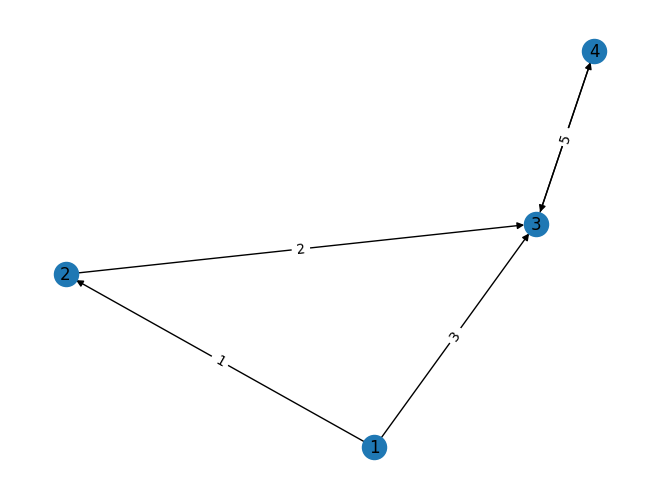

In [9]:
wgraph.plot(1)

In [10]:
dist, prev = wgraph.Dijkstra(1)
print(dist)
print(prev)

{1: 0, 2: 1, 3: 3, 4: 8}
{1: None, 2: 1, 3: 1, 4: 3}


In [11]:
!wget https://raw.githubusercontent.com/pgordin/OptDisc2026/refs/heads/main/weighted0.txt

--2026-05-18 09:22:12--  https://raw.githubusercontent.com/pgordin/OptDisc2026/refs/heads/main/weighted0.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 114 [text/plain]
Saving to: ‘weighted0.txt’

weighted0.txt       100%[===================>]     114  --.-KB/s    in 0s      

2026-05-18 09:22:12 (1.82 MB/s) - ‘weighted0.txt’ saved [114/114]



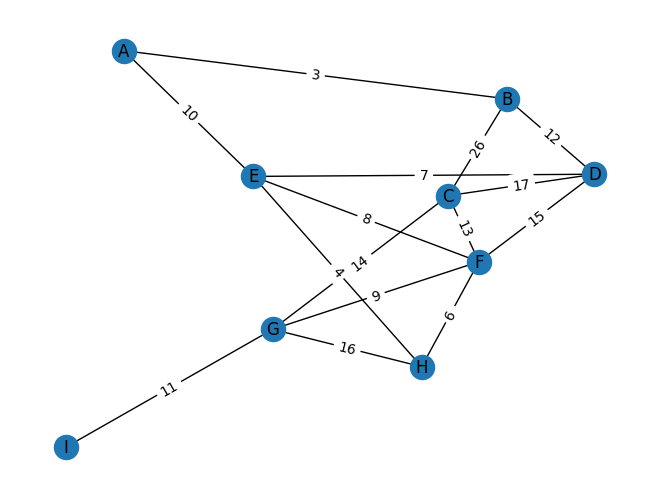

In [26]:
wgraph2 = WeightedGraph.from_edges('weighted0.txt')
wgraph2.plot()

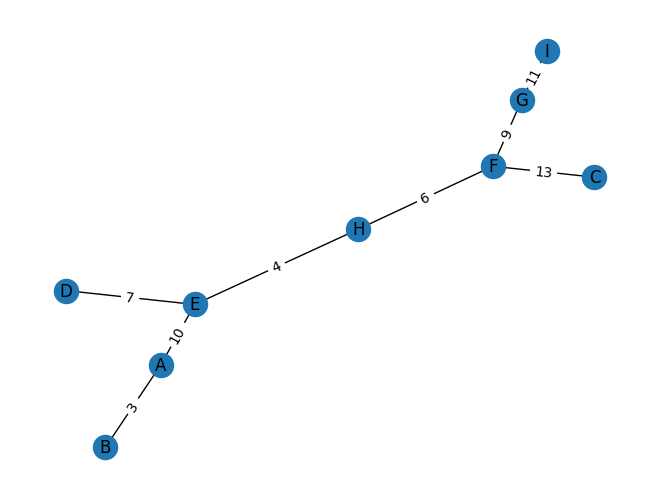

63


In [27]:
wtree, total = wgraph2.min_spanning_tree()
wtree.plot()
print(total)

In [28]:
wgraph3 = deepcopy(wgraph2)
wgraph3.add_edge(("J", "K"), 10)
wtree2, total2 = wgraph3.min_spanning_tree()
print(total2)

Graf niespojny! Zwrócono drzewo dla jednej spójnej składowej.
63


In [29]:
dist, prev = wgraph2.Dijkstra("A")
print(dist)
print(prev)

{'A': 0, 'B': 3, 'E': 10, 'C': 29, 'D': 15, 'F': 18, 'G': 27, 'H': 14, 'I': 38}
{'A': None, 'B': 'A', 'E': 'A', 'C': 'B', 'D': 'B', 'F': 'E', 'G': 'F', 'H': 'E', 'I': 'G'}


In [30]:
dist, prev = wgraph2.Dijkstra2("A")
print(dist)
print(prev)

{'A': 0, 'B': 3, 'E': 10, 'C': 29, 'D': 15, 'F': 18, 'G': 27, 'H': 14, 'I': 38}
{'A': None, 'B': 'A', 'E': 'A', 'C': 'B', 'D': 'B', 'F': 'E', 'G': 'F', 'H': 'E', 'I': 'G'}


Test wydajności

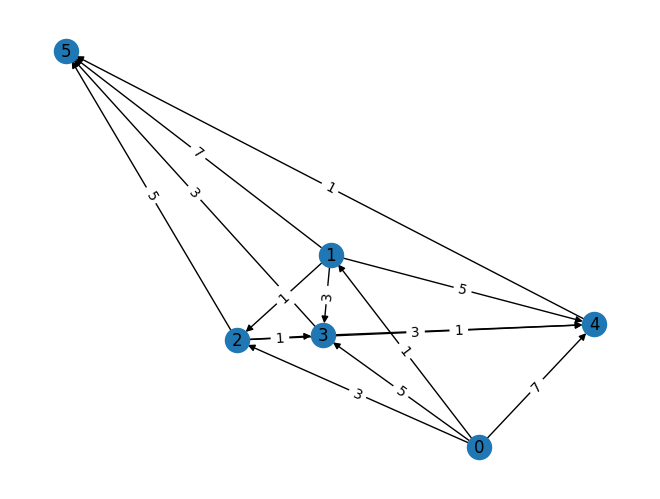

In [46]:
n = 6
test1 = WeightedGraph()
for i in range(n):
  test1.add_vertex(i)
for x in range(1, n-1):
  for u in range(n-x):
    test1.add_arc((u, u+x), 2*x-1)

test1.plot(1)

In [47]:
dist, pred = test1.Dijkstra(0)
print(dist)
print(pred)

{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5}
{0: None, 1: 0, 2: 1, 3: 2, 4: 3, 5: 4}


In [48]:
dist, pred = test1.Dijkstra2(0)
print(dist)
print(pred)

{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5}
{0: None, 1: 0, 2: 1, 3: 2, 4: 3, 5: 4}


In [49]:
dist, pred = test1.Dijkstra3(0)
print(dist)
print(pred)

{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5}
{0: None, 1: 0, 2: 1, 3: 2, 4: 3, 5: 4}


In [54]:
n = 500
test2 = WeightedGraph()
for i in range(n):
  test2.add_vertex(i)
for x in range(1, n-1):
  for u in range(n-x):
    test2.add_arc((u, u+x), 2*x-1)

In [55]:
%timeit dist, pred = test2.Dijkstra(0)

672 ms ± 9.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [56]:
%timeit dist, pred = test2.Dijkstra2(0)

202 ms ± 34.8 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [57]:
%timeit dist, pred = test2.Dijkstra3(0)

1.37 s ± 217 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Przechodzenie grafów

### Spójne składowe

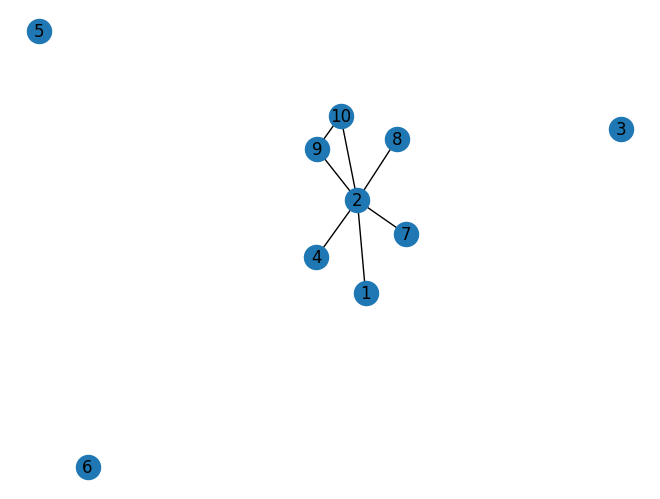

In [ ]:
seed(2026)  # dla powtarzalności
graph = Graph.random_graph(10, 0.22)
graph.plot()

In [ ]:
print(graph.connected_components())

[{1, 2, 3, 4, 5, 6, 7, 8, 9, 10}, {1, 2, 4, 7, 8, 9, 10}, {3}, {5}, {6}]


In [ ]:
comp_graphs = graph.connected_components_graphs()
for g in comp_graphs:
  print(g)

1: 2
2: 1 4 7 8 9 10
4: 2
7: 2
8: 2
9: 2 10
10: 2 9

3:

5:

6:



In [ ]:
print(graph.distance(1))

{1: 0, 2: 1, 4: 2, 7: 2, 8: 2, 9: 2, 10: 2}


In [ ]:
graph2 = Graph.random_graph(100, 0.04)
print(len(graph2.connected_components()))
print(graph2.connected_components())


6
[{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100}, {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100}, {13}, {43}, {58}, {88}]


## Eksperyment Millgrama (małego świata)

Zbadamy, czy $G(n, p)$ jest dobrym modelem zjawiska

In [ ]:
n = 2000
p = 1/500
rgraph = Graph.random_graph(n, p)
print(len(rgraph.connected_components())-1)
graph = rgraph.connected_components_graphs()[0]
print(len(graph.vertices()))

43
1958


In [ ]:
md = {}
ecc = {}
for v in graph.vertices():
  dist = graph.distance(v)
  ecc[v] = max(dist.values())
  md[v] = sum(dist.values())/len(dist)
print("Promień: ", min(ecc.values()))
print("Średnica: ", max(ecc.values()))
print("Średnio: ", sum(md.values())/len(md))

Promień:  8
Średnica:  12
Średnio:  5.591610229528995


## Kody Prüfera

In [ ]:
%%writefile edges.txt
1 3
3 5
2 5
4 5
5 6

Overwriting edges.txt


1: 3
3: 1 5
5: 3 2 4 6
2: 5
4: 5
6: 5



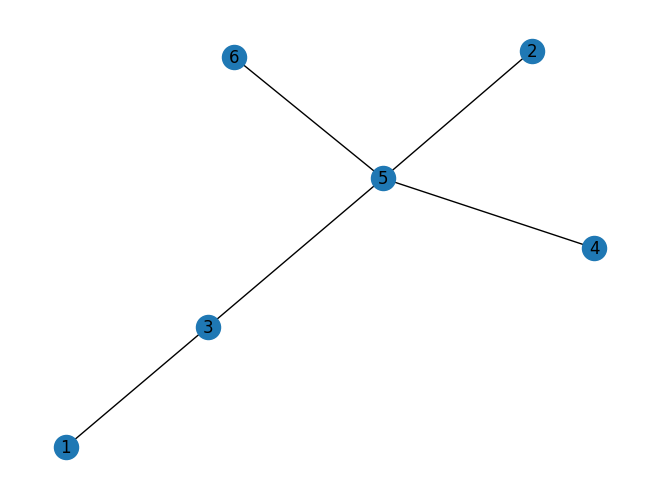

In [ ]:
tree1 = Graph.from_edges('edges.txt')
print(tree1)
tree1.plot()

In [ ]:
print(tree1.Prufer())

3 5 5 5


In [ ]:
print(tree1)

1: 3
3: 1 5
5: 3 2 4 6
2: 5
4: 5
6: 5



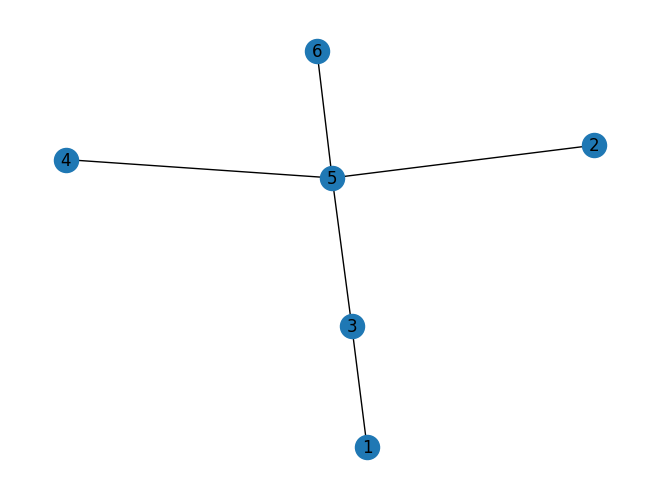

In [ ]:
Graph.tree_from_Prufer("3 5 5 5").plot()

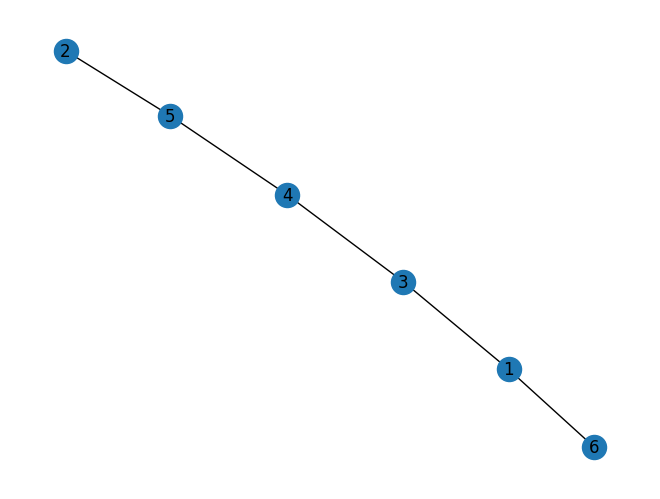

In [ ]:
Graph.tree_from_Prufer("5 4 3 1").plot()

## Wczytywanie i zapis grafów

In [ ]:
%%writefile edges.txt
a b
a c
b d
c e
f

Writing edges.txt


In [ ]:
%cat edges.txt

a b
a c
b d
c e
f


In [ ]:
graph1 = Graph.from_edges('edges.txt')

In [ ]:
print(graph1)

a: b c
b: a d
c: a e
d: b
e: c
f:



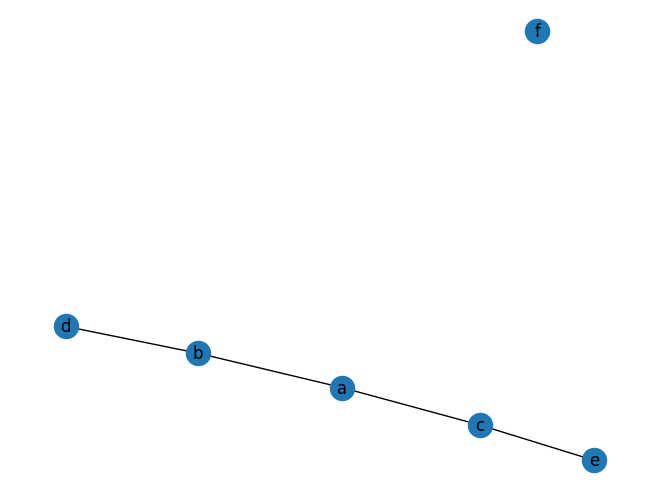

In [ ]:
graph1.plot()

In [ ]:
digraph1 = Graph.from_edges('edges.txt', directed=1)
print(digraph1)

a: b c
b: d
c: e
d:
e:
f:



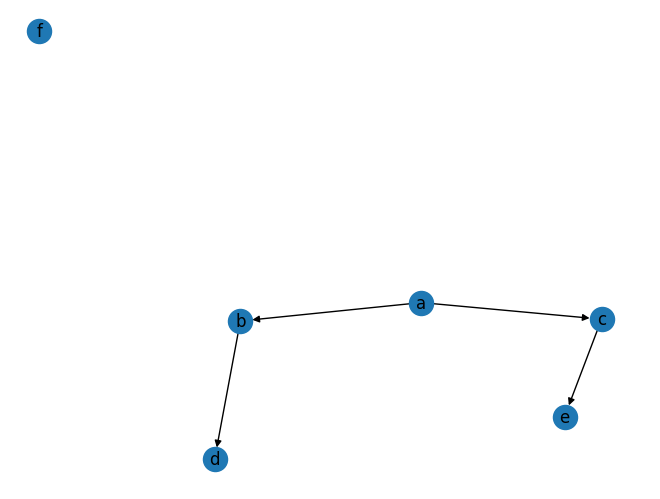

In [ ]:
digraph1.plot(directed=True)

In [ ]:
!wget https://raw.githubusercontent.com/pgordin/OptDisc2026/refs/heads/main/weighted0.txt

--2026-04-20 09:11:40--  https://raw.githubusercontent.com/pgordin/OptDisc2026/refs/heads/main/weighted0.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 114 [text/plain]
Saving to: ‘weighted0.txt’

weighted0.txt       100%[===================>]     114  --.-KB/s    in 0s      

2026-04-20 09:11:40 (3.74 MB/s) - ‘weighted0.txt’ saved [114/114]



In [ ]:
%cat weighted0.txt

A B 3
A E 10
B C 26
B D 12
C D 17
C F 13
C G 14
D E 7
D F 15
E F 8
E H 4
F G 9
F H 6
G H 16
G I 11


In [ ]:
graph2 = Graph.from_edges('weighted0.txt')
print(graph2)

A: B E
B: A C D
E: A D F H
C: B D F G
D: B C E F
F: C D E G H
G: C F H I
H: E F G
I: G



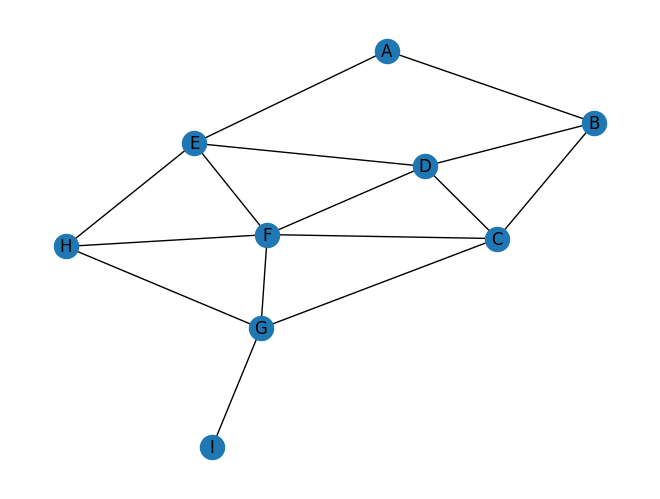

In [ ]:
graph2.plot()

In [ ]:
Graph.to_neighbourlist(graph2, 'graph2.txt')

In [ ]:
%cat graph2.txt

A: B E
B: A C D
E: A D F H
C: B D F G
D: B C E F
F: C D E G H
G: C F H I
H: E F G
I: G


In [ ]:
print(Graph.from_neighbourlist('graph2.txt'))

A: B E
B: A C D
E: A D F H
C: B D F G
D: B E C F
F: E C D G H
H: E F G
G: C F H I
I: G



In [ ]:
graph2.to_edges('graph2b.txt', directed=False)

In [ ]:
%cat graph2b.txt

A B
A E
B C
B D
E D
E F
E H
C D
C F
C G
D F
F G
F H
G H
G I


In [ ]:
seed(2026)  # dla powtarzalności
graph3 = Graph.random_graph(10, 1/3)

In [ ]:
print(graph3)

1: 2
2: 1 4 7 8 9 10
3: 4 8
4: 2 3
5: 6 9
6: 5
7: 2
8: 2 3
9: 2 5 10
10: 2 9



In [ ]:
print(Graph.cycle(6))

1: 2 6
2: 1 3
3: 2 4
4: 3 5
5: 4 6
6: 5 1



## Pierwsze zajęcia

In [ ]:
vertices = ['a', 'b', 'c', 'd']
matrix = np.array([[0,1,1,1],[1,0,0,0],[1,0,0,0],[1,0,0,0]])

In [ ]:
print(vertices)

['a', 'b', 'c', 'd']


In [ ]:
print(matrix)

[[0 1 1 1]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]]


In [ ]:
print_matrix(vertices, matrix)

a :  b  c  d
b :  a
c :  a
d :  a


In [ ]:
print_matrix(None, matrix)

1 :  2  3  4
2 :  1
3 :  1
4 :  1


In [ ]:
print_matrix(['a','b'], matrix)

1 :  2  3  4
2 :  1
3 :  1
4 :  1


In [ ]:
graph = {
    'a': ['b', 'c', 'd'],
    'b': ['a'],
    'c': ['a'],
    'd': ['a']
}

In [ ]:
print(graph)

{'a': ['b', 'c', 'd'], 'b': ['a'], 'c': ['a'], 'd': ['a']}


In [ ]:
print_dict(graph)

a :  b  c  d
b :  a
c :  a
d :  a


In [ ]:
graph0 = Graph(graph)
print(graph0)

a: b c d
b: a
c: a
d: a



In [ ]:
graph0.add_vertex('e')

In [ ]:
graph0.add_edge(('a', 'f'))

In [ ]:
print(graph0)

a: b c d f
b: a
c: a
d: a
e:
f: a



In [ ]:
graph0.add_edge(('e', 'f'))

In [ ]:
graph0.add_edge(('f', 'f'))

ValueError: Pętle nie są dopuszczalne!

In [ ]:
graph0.add_arc(('f', 'f'))

In [ ]:
print(graph0)

a: b c d f
b: a
c: a
d: a
e: f
f: a e f

